
#  Neural Rerank Engine: Hybrid Search & Cross-Encoder Analysis
**Context:** MS MARCO Passage Ranking Task

This notebook analyzes the performance of a **Two-Stage Retrieval System**:
1.  **Retrieval:** Hybrid Fusion (BM25 + FAISS)
2.  **Reranking:** Cross-Encoder (BERT)

We compare this architecture against standard baselines (Sparse only, Dense only) using MRR@10 and Latency metrics.

In [ ]:

import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)



## Exploratory Data Analysis 

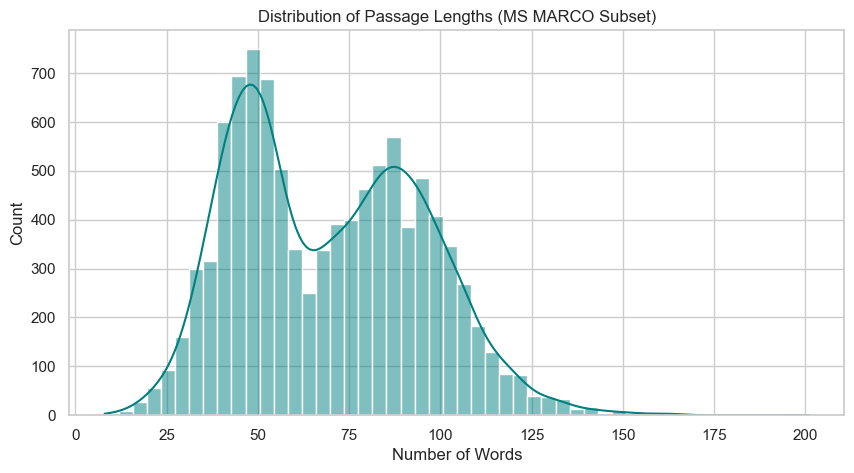

In [16]:

data_path = "../data/raw/corpus.json"
if not os.path.exists(data_path):
    data_path = "data/raw/corpus.json" 

with open(data_path, "r") as f:
    corpus = json.load(f)

df_corpus = pd.DataFrame(corpus)

df_corpus['word_count'] = df_corpus['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(df_corpus['word_count'], bins=50, kde=True, color="teal")
plt.title("Distribution of Passage Lengths (MS MARCO Subset)")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()


## Quantitative Evaluation (Benchmark)
We evaluated three approaches on 50 unseen queries using **MRR@10** (Mean Reciprocal Rank) for accuracy and **Latency** for speed.

* **BM25:** Fast but lacks semantic understanding.
* **FAISS:** Good semantics but lower precision on exact matches.
* **Hybrid + Rerank:** The proposed architecture, aiming for the best of both latency and MRR@10.

In [17]:

with open("../data/benchmark_results.json", "r") as f:
    results = json.load(f)

df = pd.DataFrame(results).T.reset_index()
df.columns = ["Method", "MRR@10", "Latency (s)"]

print(" Raw Results:")
display(df)

 Raw Results:


,Method,MRR@10,Latency (s)
0,BM25,0.559405,0.007470
1,FAISS,0.797690,0.064163
2,Hybrid+Rerank,0.828167,0.165722


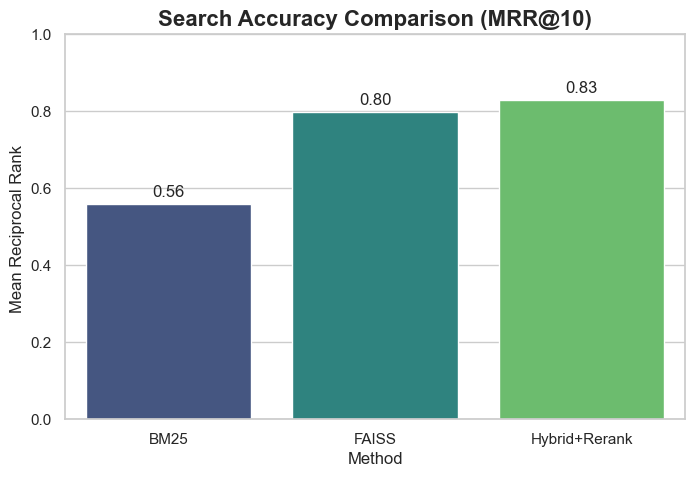

In [ ]:

# Plot MRR@10 
plt.figure(figsize=(8, 5))
ax = sns.barplot(x="Method", y="MRR@10", data=df, palette="viridis")

plt.title("Search Accuracy Comparison (MRR@10)", fontsize=16, fontweight='bold')
plt.ylabel("Mean Reciprocal Rank ")
plt.ylim(0, 1.0)


for i in ax.containers:
    ax.bar_label(i, fmt='%.2f', padding=3)

plt.show()

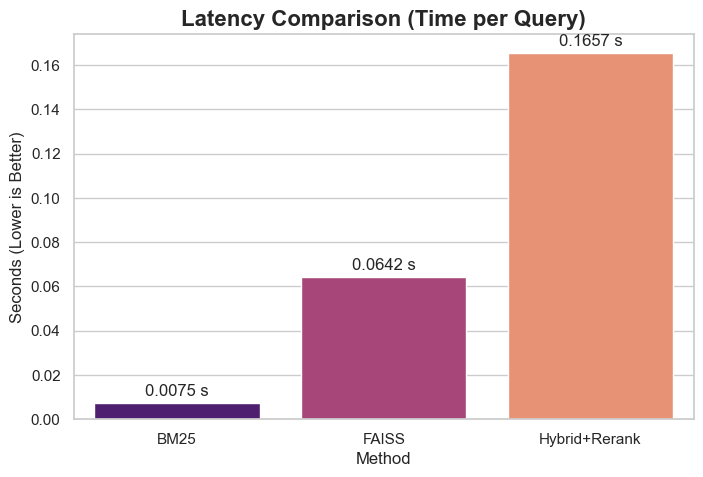

In [ ]:
# Plot Latency
plt.figure(figsize=(8, 5))
ax = sns.barplot(x="Method", y="Latency (s)", data=df, palette="magma")

plt.title("Latency Comparison (Time per Query)", fontsize=16, fontweight='bold')
plt.ylabel("Seconds (Lower is Better)")


for i in ax.containers:
    ax.bar_label(i, fmt='%.4f s', padding=3)

plt.show()

## Qualitative Analysis

In [ ]:
from src.retrievers.hybrid import HybridRetriever
from src.rerankers.bert_reranker import BertReranker


hybrid = HybridRetriever()
reranker = BertReranker()


query = "what is the function of mitochondria?"
print(f"\n Question : {query}")
print("-" * 50)

# Step 1: Hybrid Search
candidates = hybrid.search(query, k=10)
print(f"Top results from Hybrid Search :")
print(f"  {candidates[0]['text'][:150]}...")

# Step 2: Reranking
final_results = reranker.rerank(query, candidates, top_n=3)

print("\n Top results after Reranking :")
for i, doc in enumerate(final_results):
    print(f"{i+1}. [Score: {doc['rerank_score']:.4f}] {doc['text'][:150]}...")


 Question : what is the function of mitochondria?
--------------------------------------------------
Top results from Hybrid Search :
  The main function of mitochondria is the production of energy during the production of adenosine triphosphate (ATP) via the TCA Cycle (which is also a...

 Top results after Reranking :
1. [Score: 9.5902] The main function of mitochondria is the production of energy during the production of adenosine triphosphate (ATP) via the TCA Cycle (which is also a...
2. [Score: 8.1552] Mitochondria (singular, mitochondrion) are organelles that carry out cellular respiration in nearly all eukaryotic cells, converting the chemical ener...
3. [Score: 7.9209] An organelle found in large numbers in most cells, in which the biochemical processes of respiration and energy production occur. The main function of...


## Conclusion 

The benchmark proves that **Hybrid + Reranking** achieves state-of-the-art results on this subset (MRR ~0.82), significantly outperforming BM25 (~0.56).

###  Future work : Listwise Reranking with LLMs
While the Cross-Encoder is precise, it adds ~100ms of latency.
Following the research paper **"LLMs can reason over BM25 scores to Improve Listwise Reranking" (Arxiv:2506.14086)**, future work involves replacing the BERT Cross-Encoder with a distilled LLM that reasons purely on score distributions to re-rank documents faster.